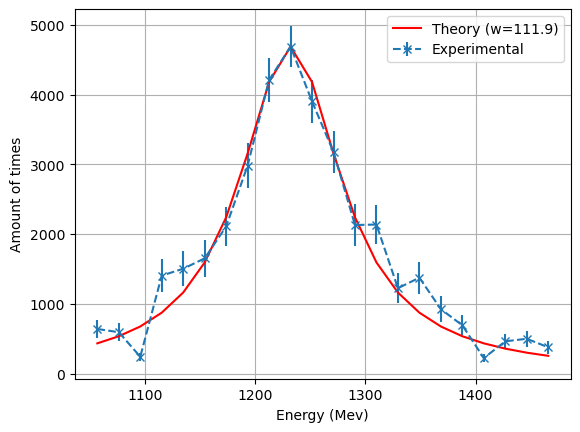

The experimental graph starts off pretty low and then dips down a bit,it starts to steadily increase until it shoots up to a peak in the middle just under 5000. 
            Then it drops off very quickly and keeps gradually falling.At the end it flattens out with a few bumps
Overall both the experimental and theoretical graph follow the same trend, both peaking at around the same position. 
        #The experimental is less smooth and has small fluctuations and deviations from the ideal curve
        #his is likely due tp statistical uncertainties and measurement noise
w=55.9, discrepancy=4.15e+03
w=89.5, discrepancy=3.08e+02
w=167.8, discrepancy=3.21e+02
w=223.8, discrepancy=5.63e+02

Best-fit w = 113.63 ± 4.88 MeV
Chi² = 99.98
Reduced Chi² = 4.76
Degrees of freedom = 21


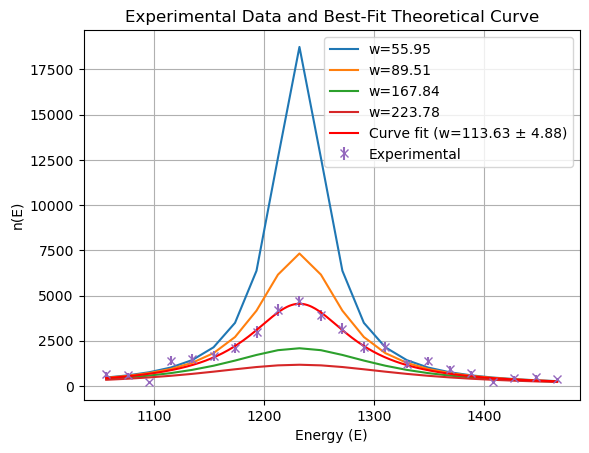

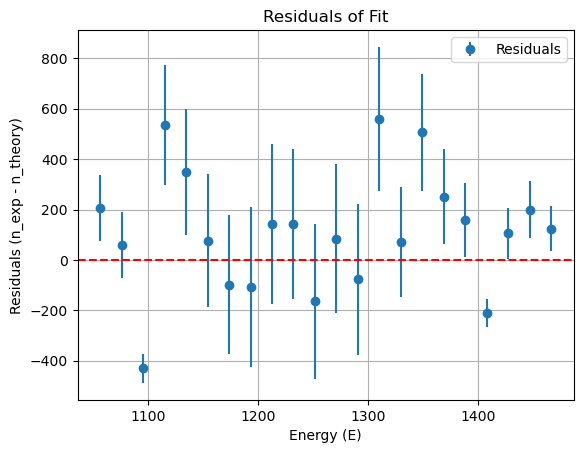

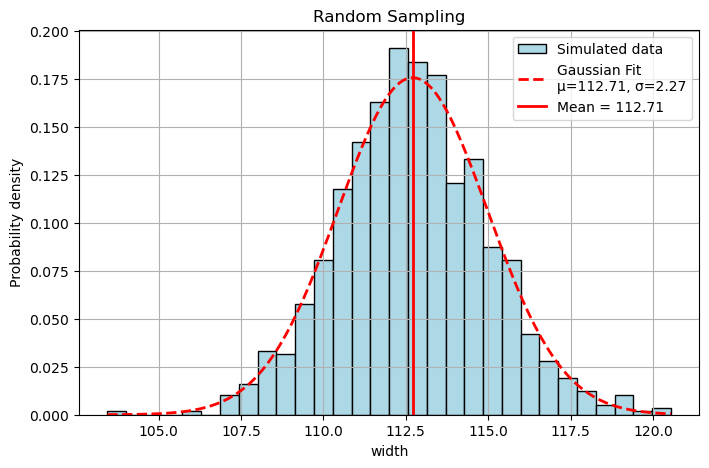

In [13]:
import numpy as np 
import matplotlib.pyplot as plt 
from numpy import array 
from scipy.optimize import curve_fit 
from scipy.stats import norm #allows me to use gaussian distribution 

#2.1
f = open('C:/Users/jdwr1g24/OneDrive - University of Southampton/Phys_2022/data1.txt', 'r') #opens the file,had to use long one as it wasn't working 
ea = []; na = []; dn = [] #empty lists to store 

for line in f: #loops through each line 
    estr, nstr, errstr = line.split() #Reads each line:enrgy,counts,uncertainity and stors them
    ea.append(float(estr)) #converts them into floats
    na.append(float(nstr))
    dn.append(float(errstr))
f.close()

ea = array(ea) #Converts lists to arrays
na = array(na)
dn = array(dn)

plt.errorbar(ea, na, yerr=dn,fmt='x--',label="Experimental") #creates my first graph with error bar

#2.2/2.3
def theory(e,w): 
    return 1.467e7/((w**2)/4+(e-1232)**2)
mid_index=np.argmax(na)
ea_mid=ea[mid_index] #was told to find the middle one 
na_mid=na[mid_index]

w = 2 * np.sqrt(1.467e7/na_mid - (ea_mid - 1232)**2) #Solving for W as I am using the middle of ea and na and substituting them
#print("Estimated w =", w)

th=theory(ea,w)#calculating the theoretical counts
plt.plot(ea, th, 'r-', label=f"Theory (w={w:.1f})")
plt.xlabel("Energy (Mev)")
plt.ylabel("Amount of times")
plt.legend()
plt.grid(True)
plt.show()

#My explanation of the experimental graph and comparing it to the theoretical graph
print("""The experimental graph starts off pretty low and then dips down a bit,it starts to steadily increase until it shoots up to a peak in the middle just under 5000. 
            Then it drops off very quickly and keeps gradually falling.At the end it flattens out with a few bumps""") #My explanation of the graph

print("""Overall both the experimental and theoretical graph follow the same trend, both peaking at around the same position. 
        #The experimental is less smooth and has small fluctuations and deviations from the ideal curve
        #his is likely due tp statistical uncertainties and measurement noise""") #My comparison of the graphs

#2.4
ws=[w*0,w*0.5,w*0.8,w*1.5,w*2] #A few values I want to try so I can sau what happens as w increases
#plt.errorbar(ea, na, yerr=dn,fmt='x--',label="Experimental") 
plt.grid(True)
for w_test in ws: #I had to do this as ws wasn't working by itself
    if w_test==0:
        continue
    plt.plot(ea, theory(ea, w_test), label=f"w={w_test:.2f}")

#2.4
def  discrepancy(w): 
    r=na-theory(ea,w) #residual is the experimental data-theoretical data
    return np.sum((r/dn)**2)

for w_test in ws[1:]:  #Once again I had to do this
    print(f"w={w_test:.1f}, discrepancy={discrepancy(w_test):.2e}")


#2.5 curve fit
popt,pcov = curve_fit(theory,ea,na,None,dn)
#print(popt)
#print(pcov)
w_fit = popt[0]
w_err = np.sqrt(np.diag(pcov))[0]  # np diag allows me to go diagonal on the covariance matrix

print(f"\nBest-fit w = {w_fit:.2f} ± {w_err:.2f} MeV")

#This is optional,Calculate r, chi2, and reduced chi2
th_model = theory(ea, w_fit)
residuals = na - th_model
chi2 = np.sum((residuals / dn) ** 2)
dof = len(ea) - len(popt)  # degrees of freedom = data points - parameters
red_chi2 = chi2 / dof

print(f"Chi² = {chi2:.2f}")
print(f"Reduced Chi² = {red_chi2:.2f}")
print(f"Degrees of freedom = {dof}")

# Plot experimental data and fitted theoretical curve
plt.errorbar(ea, na, yerr=dn, fmt='x', label='Experimental')
E_fit = np.linspace(ea.min(), ea.max(), 400)
plt.plot(E_fit, theory(E_fit, w_fit), 'r-', label=f'Curve fit (w={w_fit:.2f} ± {w_err:.2f})')
plt.xlabel("Energy (E)")
plt.ylabel("n(E)")
plt.legend()
plt.title("Experimental Data and Best-Fit Theoretical Curve")
plt.grid(True)
plt.show()

# Optional, plotting my residuals on a graph so I can visiual
plt.errorbar(ea, residuals, yerr=dn, fmt='o', label='Residuals') 
plt.axhline(0, color='r', linestyle='--') #Horizontal line
plt.xlabel("Energy (E)")
plt.ylabel("Residuals (n_exp - n_theory)")
plt.legend()
plt.title("Residuals of Fit")
plt.grid(True)
plt.show()

N_students = 1000 
ws_students = np.zeros(N_students) #stores each w value

# Random sampling 
for i in range(N_students):
    random_na = np.random.normal(na, dn)
    popt, _ = curve_fit(theory, ea, random_na, p0=[w_fit])
    ws_students[i] = popt[0]

# Calculating mean and standard deviation 
mean_w = np.mean(ws_students)
std_w = np.std(ws_students, ddof=1)

# Plotting my histogram  
plt.figure(figsize=(8,5))
counts, bins, patches = plt.hist(ws_students, bins=30, density=True, color='lightblue',
                                 edgecolor='black',  label='Simulated data')

# Gaussian curve,optional
x_height = np.linspace(min(bins), max(bins), 200) #line space generates 200 even spaced x values between smallest and largest. Would look choppy if x=bins
Gauss_vals = norm.pdf(x_height, mean_w, std_w)
plt.plot(x_height, Gauss_vals, 'r--', linewidth=2, label=f'Gaussian Fit\nμ={mean_w:.2f}, σ={std_w:.2f}')

# Mean vertical line
plt.axvline(mean_w, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean_w:.2f}')

# Labels
plt.xlabel("width")
plt.ylabel("Probability density")
plt.title("Random Sampling")
plt.grid(True)
plt.legend()
plt.show()
